# Phase 5 Report Figures

Four figures for the written recommendation, built directly from the same derived
tables the rest of this project's SQL pipeline produced. Nothing here is a new
analysis — it's the existing scoring and matching work, visualized.

- **Figure 1** — the real occupations behind each finalist's labor-demand score
- **Figure 2** — why fields are ranked by percentile position, not raw completions count
- **Figure 3** — how the composite score is built: the five weighted factors
- **Figure 4** — the strongest candidates vs. Vanderbilt's own 15-program catalog, scored the same way, as a baseline

Run top to bottom. Each figure is also saved to `output/` (alongside this notebook) as a
PNG for the report, so every image in the report traces back to the exact code that made it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

os.makedirs("output", exist_ok=True)  # this notebook's generated figures live here

# Same validated categorical palette used for the Phase 4 dashboard figures,
# checked for colorblind safety with the dataviz skill's palette validator.
BLUE, ORANGE, GREEN, GOLD, PINK = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
GREY = "#9a9a9a"
DARK = "#1c1c1c"

plt.rcParams.update({
    "font.size": 11,
    "axes.edgecolor": "#cccccc",
    "axes.labelcolor": DARK,
    "text.color": DARK,
    "xtick.color": DARK,
    "ytick.color": DARK,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

derived = pd.read_csv("../data/derived/derived_candidates.csv", dtype={"cip2020_code": str})
scored = pd.read_csv("../data/derived/scored_candidates.csv", dtype={"cip2020_code": str})
openings = pd.read_csv("../data/clean/bls_occupational_openings_clean.csv")
fastest_growing = pd.read_csv("../data/clean/bls_fastest_growing_clean.csv")
most_new_jobs = pd.read_csv("../data/clean/bls_most_new_jobs_clean.csv")

top30_socs = set(fastest_growing["soc_code"]) | set(most_new_jobs["soc_code"])

FINALISTS = {
    "30.7001": "Data Science",
    "11.0104": "Applied Informatics",
    "45.0603": "Quantitative Economics",
    "30.7102": "Business Analytics",
    "11.0401": "Information Science",
}
print(f"{len(derived)} candidates loaded, {len(openings)} BLS occupations loaded")

1268 candidates loaded, 832 BLS occupations loaded


## Figure 1 — The real jobs behind each finalist's labor-demand score

Each finalist's labor-demand number isn't one abstract figure. It comes from that
field's three most closely related occupations (by 2024 employment size), matched
through the government's CIP-to-SOC crosswalk in Phase 2. This figure shows those
occupations by name, with their actual projected growth rate through 2034, and flags
which ones also appear on BLS's own published lists of the fastest-growing or highest-
volume occupations in the country.

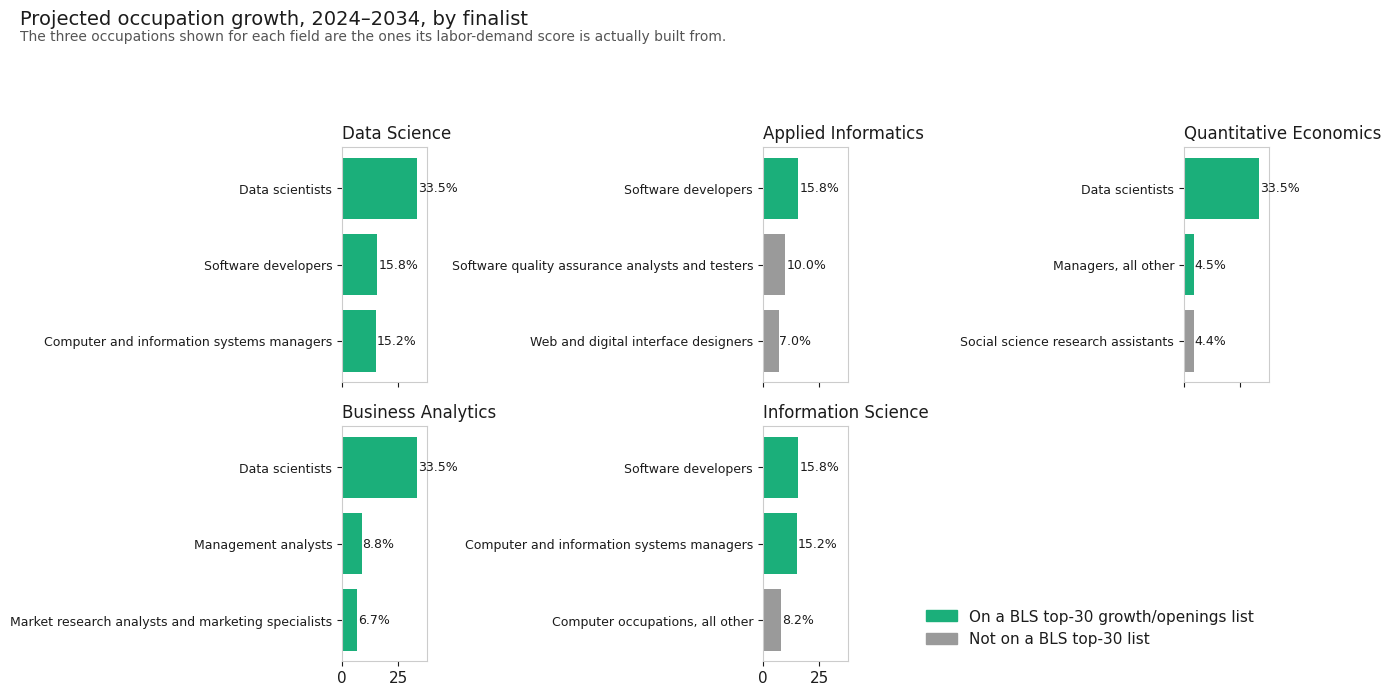

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
axes = axes.flatten()

for ax, (cip, name) in zip(axes, FINALISTS.items()):
    row = derived.loc[derived["cip2020_code"] == cip].iloc[0]
    socs = [s.strip() for s in row["matched_soc_codes"].split(",")]
    occ = openings[openings["soc_code"].isin(socs)].copy()
    occ = occ.set_index("soc_code").loc[socs].reset_index()  # keep original order
    occ = occ.sort_values("employment_change_percent_2024_34")
    colors = [GREEN if s in top30_socs else GREY for s in occ["soc_code"]]
    ax.barh(occ["occupation_title"], occ["employment_change_percent_2024_34"], color=colors)
    for y, v in enumerate(occ["employment_change_percent_2024_34"]):
        ax.text(v + 0.4, y, f"{v:.1f}%", va="center", fontsize=9)
    ax.set_title(name, fontsize=12, loc="left")
    ax.set_xlim(0, 38)
    ax.tick_params(axis="y", labelsize=9)

axes[-1].axis("off")
handles = [mpatches.Patch(color=GREEN, label="On a BLS top-30 growth/openings list"),
           mpatches.Patch(color=GREY, label="Not on a BLS top-30 list")]
fig.legend(handles=handles, loc="lower right", bbox_to_anchor=(0.98, 0.06), frameon=False)
fig.suptitle("Projected occupation growth, 2024–2034, by finalist", fontsize=14, x=0.02, y=0.99, ha="left")
fig.text(0.02, 0.945, "The three occupations shown for each field are the ones its labor-demand score is actually built from.",
          fontsize=10, color="#555555")
fig.tight_layout(rect=[0, 0, 1, 0.90])
fig.savefig("output/fig1_occupations_by_finalist.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2 — Why fields are ranked by position, not by raw completions count

National completions data is heavily skewed: a small number of catch-all fields are
enormous compared to almost everything else. This figure plots the full distribution
(p10 through p90, from `docs/planning/phase3-scoring-findings.md`) on a log scale,
marks the single largest field in the dataset, and shows where the five finalists
actually sit. The gap between the outlier and the p90 line is the reason every field
is scored by its rank position rather than its raw number.

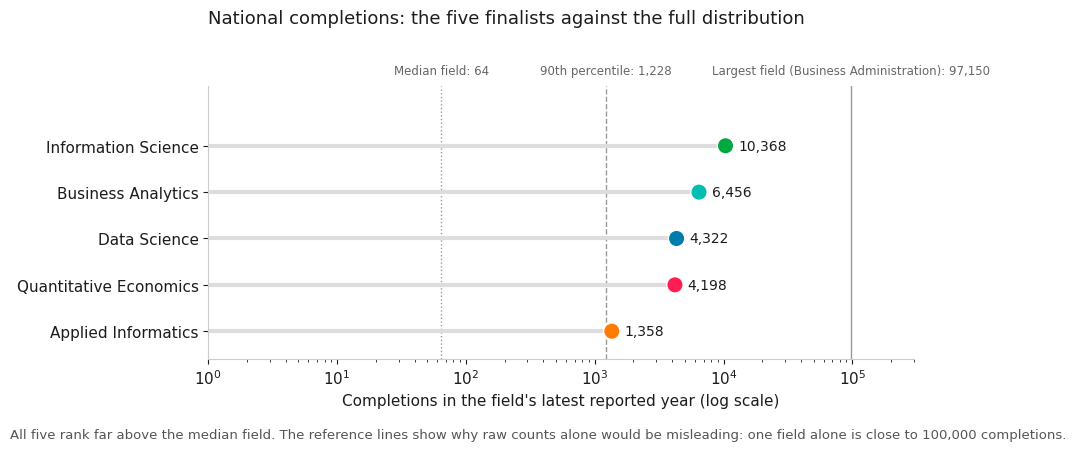

In [3]:
# Distribution profile for completions_latest_year, from the Phase 3 findings report
# (n=1,268; independently verified against the source data in
# notebooks/phase3_ai_report_verification.ipynb)
percentiles = {"p10": 0.7, "p25": 10, "median": 64.5, "p75": 326.3, "p90": 1227.5}
outlier_value = 97150

# Same per-program colors used on the Tableau dashboard, kept identical here so a
# reader can carry a color from one artifact to the other without relearning it.
PROGRAM_COLORS = {
    "Applied Informatics": "#FF7A00",
    "Business Analytics": "#00BDB2",
    "Data Science": "#007DAC",
    "Information Science": "#00A83F",
    "Quantitative Economics": "#FF1E54",
}

# Ordered so the chart reads top-to-bottom by rank, matching the finalists table
finalist_values = [
    ("Information Science", 10368),
    ("Business Analytics", 6456),
    ("Data Science", 4322),
    ("Quantitative Economics", 4198),
    ("Applied Informatics", 1358),
]
colors = [PROGRAM_COLORS[name] for name, _ in finalist_values]

fig, ax = plt.subplots(figsize=(10, 4.5))
names = [n for n, _ in finalist_values]
values = [v for _, v in finalist_values]
y_pos = np.arange(len(names))

ax.hlines(y_pos, 1, values, color="#dddddd", linewidth=3, zorder=1)
ax.scatter(values, y_pos, color=colors, s=140, zorder=3, edgecolor="white", linewidth=1)
for y, v in zip(y_pos, values):
    ax.text(v * 1.25, y, f"{v:,}", va="center", fontsize=10)

ax.set_xscale("log")
ax.set_xlim(1, 300000)
ax.set_ylim(len(names) - 0.4, -1.3)  # extra headroom above the rows for reference labels
ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=11)
ax.set_xlabel("Completions in the field's latest reported year (log scale)")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.set_title("National completions: the five finalists against the full distribution", loc="left", fontsize=13, pad=45)

# Reference lines for where the typical field and the largest field sit, labeled
# above the plotted rows (in axes-fraction height) so they never collide with the dots
blend = ax.get_xaxis_transform()
for val, label, style in [
    (percentiles["median"], f"Median field: {percentiles['median']:.0f}", ":"),
    (percentiles["p90"], f"90th percentile: {percentiles['p90']:,.0f}", "--"),
    (outlier_value, f"Largest field (Business Administration): {outlier_value:,}", "-"),
]:
    ax.axvline(val, color="#999999", linestyle=style, linewidth=1, zorder=0, ymax=1)
    ax.text(val, 1.03, label, transform=blend, rotation=0, fontsize=8.5, color="#666666", ha="center", va="bottom")

fig.text(0.01, 0.01,
          "All five rank far above the median field. The reference lines show why raw counts alone would be misleading: "
          "one field alone is close to 100,000 completions.",
          fontsize=9.5, color="#555555")
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig("output/fig2_completions_skew.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3 — How the composite score is built

A single stacked bar showing the five weighted factors behind every score in this
project: 30% current enrollment size, 30% current job openings, 15% enrollment growth,
15% job growth, 10% the BLS top-30 corroborating flag. Purely illustrative — no data
computation, just the fixed weights from `sql/06`/`sql/08`.

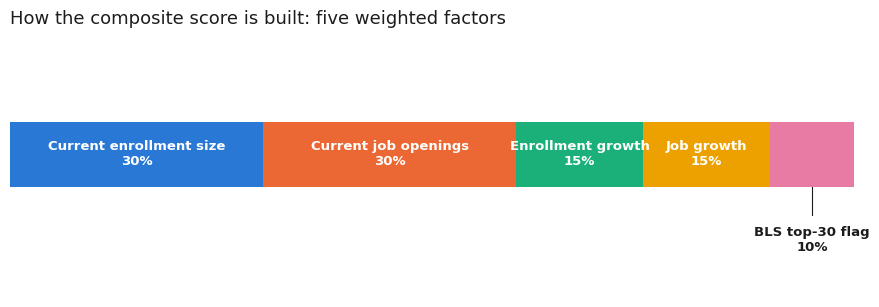

In [4]:
weight_data = [
    ("Current enrollment size", 30, BLUE),
    ("Current job openings", 30, ORANGE),
    ("Enrollment growth", 15, GREEN),
    ("Job growth", 15, GOLD),
    ("BLS top-30 flag", 10, PINK),
]

fig, ax = plt.subplots(figsize=(9, 3.2))
left = 0
for label, pct, color in weight_data:
    ax.barh(0, pct, left=left, color=color, height=0.6)
    if pct >= 15:
        ax.text(left + pct / 2, 0, f"{label}\n{pct}%", ha="center", va="center",
                fontsize=9.5, color="white", fontweight="bold")
    else:
        # narrow segment: label placed below with a leader line so text never overflows
        ax.plot([left + pct / 2, left + pct / 2], [-0.3, -0.55], color=DARK, lw=0.8)
        ax.text(left + pct / 2, -0.65, f"{label}\n{pct}%", ha="center", va="top",
                fontsize=9.5, color=DARK, fontweight="bold")
    left += pct

ax.set_xlim(0, 100)
ax.set_ylim(-1.3, 1)
ax.axis("off")
ax.set_title("How the composite score is built: five weighted factors", loc="left", fontsize=13, pad=15)
fig.tight_layout()
fig.savefig("output/fig3_composite_weights.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 4 — The candidates against Vanderbilt's own catalog, as a baseline

Two panels, both on the same 0-100 composite score, built the same way as every other
score in this project. The left panel is the top of the not-yet-offered candidate
pool: `shortlist_ranked.csv`, the 61 distinct real-world programs Phase 3 already
deduplicated from the raw 1,268 field codes (126 Go-band rows, linked into 27 clusters
of near-duplicates plus 34 true singles), cut off at a score of 80 so the differences
among genuinely strong candidates are visible instead of compressed. The right panel
scores Vanderbilt's own current 15-program online catalog the exact same way, using the
same five weighted factors, so a reader can see where today's programs already sit on
this scale, not just where the proposed ones would land.

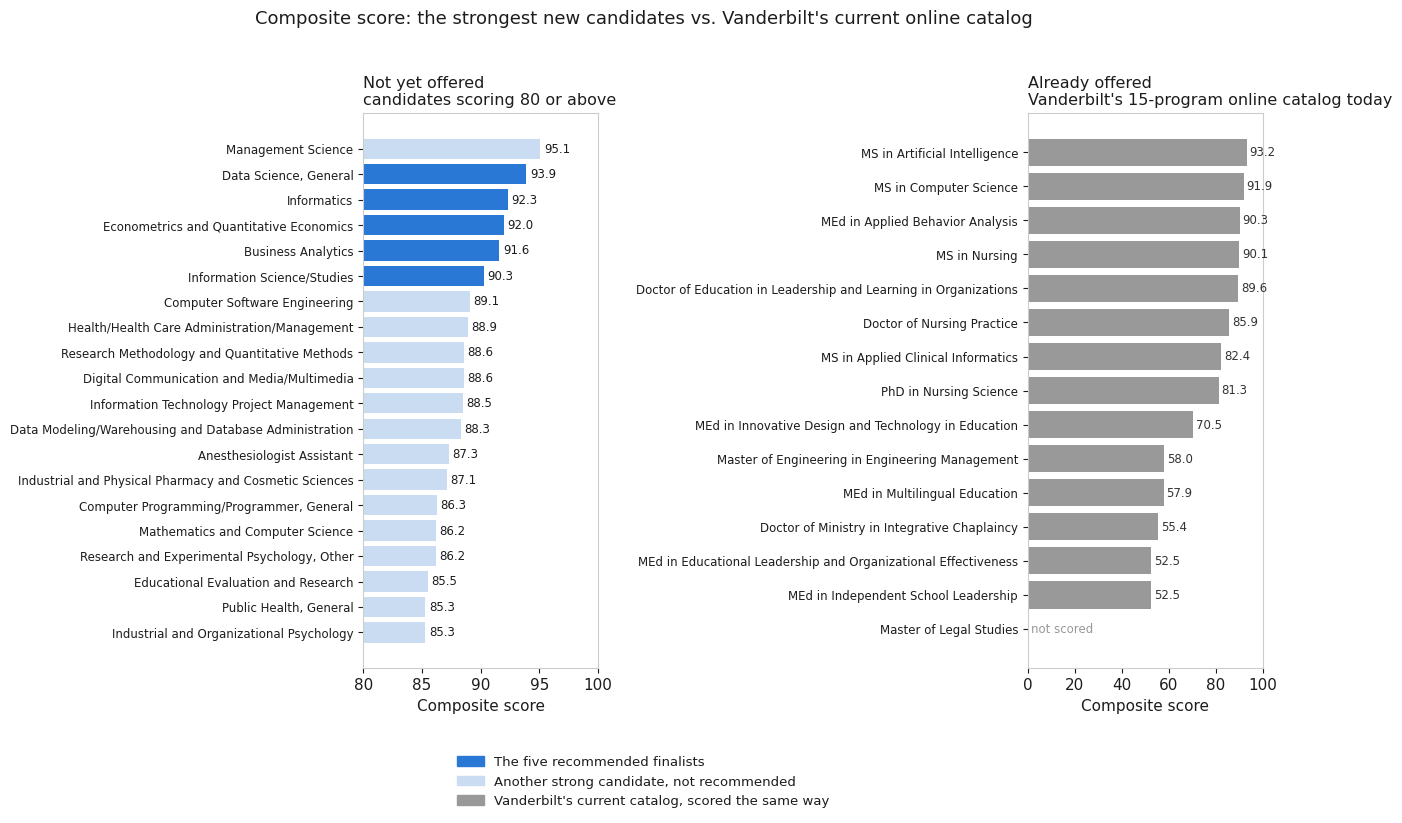

In [5]:
shortlist = pd.read_csv("../data/derived/shortlist_ranked.csv", dtype={"cip2020_code": str})
vandy = pd.read_csv("../data/clean/vanderbilt_current_programs_clean.csv", dtype={"cip2020_code": str})

finalist_cip_titles = set(scored.loc[scored["cip2020_code"].isin(FINALISTS.keys()), "cip2020_title"])

# Left panel: top 20 candidates, x-axis cut off at 80 so real differences show
candidates = shortlist[["cip2020_title", "score"]].sort_values("score", ascending=False).head(20).copy()
candidates = candidates.sort_values("score", ascending=True)
cand_colors = [BLUE if t in finalist_cip_titles else "#c9dcf2" for t in candidates["cip2020_title"]]

# Right panel: Vanderbilt's own 15-program catalog, scored the identical way.
# One program (Master of Legal Studies) has no match in the labor/completions data
# this project covers, so it's shown as unscored rather than silently dropped.
vandy_scored = vandy.merge(scored[["cip2020_code", "score"]], on="cip2020_code", how="left")
vandy_scored["label"] = vandy_scored["program_name"].str.replace("Master of Science in ", "MS in ", regex=False) \
                                                     .str.replace("Master of Education in ", "MEd in ", regex=False)
vandy_scored["plot_score"] = vandy_scored["score"].fillna(0)
vandy_scored = vandy_scored.sort_values("plot_score", ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 7.5))

ax1.barh(candidates["cip2020_title"], candidates["score"], color=cand_colors)
for y, v in enumerate(candidates["score"]):
    ax1.text(v + 0.3, y, f"{v:.1f}", va="center", fontsize=8.5)
ax1.set_xlim(80, 100)
ax1.set_xlabel("Composite score")
ax1.set_title("Not yet offered\ncandidates scoring 80 or above", loc="left", fontsize=11.5)
ax1.tick_params(axis="y", labelsize=8.5)

bar_colors2 = ["#999999" if pd.notna(s) else "#dddddd" for s in vandy_scored["score"]]
ax2.barh(vandy_scored["label"], vandy_scored["plot_score"], color=bar_colors2)
for y, (v, has_score) in enumerate(zip(vandy_scored["plot_score"], vandy_scored["score"].notna())):
    label = f"{v:.1f}" if has_score else "not scored"
    ax2.text(v + 1.2, y, label, va="center", fontsize=8.5, color="#333333" if has_score else "#999999")
ax2.set_xlim(0, 100)
ax2.set_xlabel("Composite score")
ax2.set_title("Already offered\nVanderbilt's 15-program online catalog today", loc="left", fontsize=11.5)
ax2.tick_params(axis="y", labelsize=8.5)

handles = [mpatches.Patch(color=BLUE, label="The five recommended finalists"),
           mpatches.Patch(color="#c9dcf2", label="Another strong candidate, not recommended"),
           mpatches.Patch(color="#999999", label="Vanderbilt's current catalog, scored the same way")]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=1, frameon=False, fontsize=9.5)
fig.suptitle("Composite score: the strongest new candidates vs. Vanderbilt's current online catalog", fontsize=13, y=1.02)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig("output/fig4_candidates_vs_catalog.png", dpi=150, bbox_inches="tight")
plt.show()